# Preparations

In [2]:
import pandas as pd
import math
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

# Layout

In [3]:
def mm_to_pixel(size_mm, dpi):
    """Convert millimeters to pixels based on the given DPI."""
    inches = size_mm / 25.4     # Convert mm to inches
    pixels = inches * dpi       # Convert inches to pixels
    return int(pixels)

Aviable format on "DM Fotoparadies" are:

- 127 × 89
- 152 × 102
- 169 × 114
- 178 × 127

In [4]:
# Print size
print_width_mm = 127
print_height_mm = 178

# Print layout
image_cols = 1
image_rows = 2

# Calculate size of single image included the border
image_width_mm = print_width_mm / image_cols
image_height_mm = print_height_mm / image_rows
print(f"Image size (WxH): {image_width_mm} x {image_height_mm} mm")

# Define border and calculate picture size
side_border_mm = 5
bottom_border_mm = 15
picture_width_mm = image_width_mm - 2*side_border_mm
picture_height_mm = image_height_mm - side_border_mm - bottom_border_mm
print(f"Picture size (WxH): {picture_width_mm} x {picture_height_mm} mm")

# Calculate matching aspects
aspect = picture_width_mm / picture_height_mm
print('Matching aspects (W:H): ', end='')
for i in range(1, 8):
      print(f'{i}:{round(aspect*i, 1)}', end=' | ')
print()

# Calculate optimal picture resolution
dpi = 300
picture_width_px = mm_to_pixel(picture_width_mm, dpi)
picture_height_px = mm_to_pixel(picture_height_mm, dpi)
print(f"Picture resolution (WxH) to get {dpi} dpi: {picture_width_px} x {picture_height_px}")

image_width_px = mm_to_pixel(image_width_mm, dpi)
image_height_px = mm_to_pixel(image_height_mm, dpi)

Image size (WxH): 127.0 x 89.0 mm
Picture size (WxH): 117.0 x 69.0 mm
Matching aspects (W:H): 1:1.7 | 2:3.4 | 3:5.1 | 4:6.8 | 5:8.5 | 6:10.2 | 7:11.9 | 
Picture resolution (WxH) to get 300 dpi: 1381 x 814


### Steps to perform

- copy all images to a single folder
- rename them according to the content of the image
- reshape them to the selected aspect ratio
- resizing is not necessary it will be done later automatically

# Convert Image Format (HEIC to JPEG)

All HEIC images in the source folder will be processed and saved as JPEGs in the target folder.

In [46]:
import os
from PIL import Image
from pillow_heif import register_heif_opener

# This 'registers' HEIC support with Pillow
register_heif_opener()

# Function to convert HEIC images to JPEG while preserving metadata
def convert_heic_to_jpg(source_folder, target_folder):
    if not os.path.exists(target_folder):
        os.makedirs(target_folder)

    for filename in os.listdir(source_folder):
        if filename.lower().endswith(".heic"):
            heic_path = os.path.join(source_folder, filename)
            jpg_path = os.path.join(target_folder, filename.replace(".heic", ".jpg").replace(".HEIC", ".jpg"))

            # Open the HEIC image
            image = Image.open(heic_path)

            # Extract EXIF data
            exif_data = image.info.get("exif")

            # Convert and save as JPEG
            # We use 'exif=exif_data' to ensure metadata isn't lost in translation
            if exif_data:
                image.save(jpg_path, "JPEG", exif=exif_data, quality=95)
            else:
                image.save(jpg_path, "JPEG", quality=95)

            print(f"Converted: {filename} -> {os.path.basename(jpg_path)}")

# Usage
convert_heic_to_jpg("C:/Users/thoma/OneDrive/HOCHZEIT/Fotowand/Fotos_HEIC", "C:/Users/thoma/OneDrive/HOCHZEIT/Fotowand/Fotos_JPG")

Converted: abschluss kathi und Klemi.HEIC -> abschluss kathi und Klemi.jpg
Converted: acquadome.HEIC -> acquadome.jpg
Converted: alerol o clock.HEIC -> alerol o clock.jpg
Converted: ausgehn in ibk.HEIC -> ausgehn in ibk.jpg
Converted: brunch in ibk.HEIC -> brunch in ibk.jpg
Converted: budapest.HEIC -> budapest.jpg
Converted: dienst in natters.HEIC -> dienst in natters.jpg
Converted: eishöfe.heic -> eishöfe.jpg
Converted: escape room in münchen.HEIC -> escape room in münchen.jpg
Converted: felixer weiher.HEIC -> felixer weiher.jpg
Converted: frankfurth.HEIC -> frankfurth.jpg
Converted: frühstück mit steffi.HEIC -> frühstück mit steffi.jpg
Converted: gampenpass.HEIC -> gampenpass.jpg
Converted: gletscher in islang.HEIC -> gletscher in islang.jpg
Converted: gurmeladele mit katha.HEIC -> gurmeladele mit katha.jpg
Converted: hochzeit sophie und manuel.HEIC -> hochzeit sophie und manuel.jpg
Converted: indisch mit shirin und katha.HEIC -> indisch mit shirin und katha.jpg
Converted: istambul.H

# Process Pictures

In [8]:
# Select input directory and list image files
ORIENTATION = 'quer'
path_to_input_dir = Path(f'C:/Users/thoma/OneDrive/HOCHZEIT/Fotowand/Fotos/{ORIENTATION}')
image_files = (
    list(path_to_input_dir.glob('*.jpg'))
    + list(path_to_input_dir.glob('*.jpeg'))
    + list(path_to_input_dir.glob('*.png'))
)

print(f"Found {len(image_files)} image files in {path_to_input_dir}")

# Create a list to store image information
image_info_list = []
image_info_list.append(['Filename', 'Width (px)', 'Height (px)', 'Date'])

# Loop through image files and extract information
for image_file in image_files:
    try:
        with Image.open(image_file) as img:

            filename = image_file.name
            width, height = img.size
            
            # Extract EXIF data if available and get the original datetime
            exif_data = img._getexif() # type: ignore
            if exif_data:
                datetime_original = exif_data.get(36867)

            else:
                print(f"No EXIF data found for {filename}")

            image_info_list.append([filename, width, height, datetime_original if exif_data else 'N/A']) # type: ignore

    except Exception as e:
        print(f"Error processing {image_file}: {e}")

# Create a DataFrame
image_info_df = pd.DataFrame(image_info_list[1:], columns=image_info_list[0])
image_info_file = path_to_input_dir.parent / f'image_info_{ORIENTATION}.xlsx'

# Add columns to manually add description and date corrected
image_info_df['Description'] = ''
image_info_df['Date corrected'] = ''
image_info_df = image_info_df[['Filename', 'Description', 'Width (px)', 'Height (px)', 'Date', 'Date corrected']]

image_info_df.to_excel(image_info_file, index=False)
image_info_df

Found 62 image files in C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\quer
No EXIF data found for achensee.jpg
No EXIF data found for babyparty nadia.jpg
No EXIF data found for bei stefi und darko.jpg
No EXIF data found for besuch aus mkd.JPG
No EXIF data found for brunch in ibk.jpg
No EXIF data found for cinqueterre.JPG
No EXIF data found for eppan wg ausflug.JPG
No EXIF data found for escape room in münchen.jpg
No EXIF data found for freilichtspiele.jpg
No EXIF data found for gardasee (3).JPG
No EXIF data found for geburtstag franz.JPG
No EXIF data found for gipfel obern falkomaisee.jpg
No EXIF data found for gruppenfoto wk.jpg
No EXIF data found for hamburg.JPG
No EXIF data found for hochzeit nadia und juli (2).jpg
No EXIF data found for hochzeit nadia und juli.jpg
No EXIF data found for hochzeit nadia.jpg
No EXIF data found for hochzeit_kathi.jpg
No EXIF data found for ibk in ronzone.jpg
No EXIF data found for in mk mit tante.jpg
No EXIF data found for kathas geburtstag.jpg
No EX

,Filename,Description,Width (px),Height (px),Date,Date corrected
0,achensee.jpg,,3408,2044,N/A,
1,babyparty nadia.jpg,,1971,1183,N/A,
2,bei stefi und darko.jpg,,3212,1927,N/A,
3,besuch aus mkd.JPG,,3220,1932,N/A,
4,brunch in ibk.jpg,,2873,1724,N/A,
...,...,...,...,...,...,...
57,weißenstein und dorf.JPG,,5789,3473,N/A,
58,wilten frühstücken.jpg,,3088,1853,N/A,
59,wk ausflug prag.JPG,,5851,3510,N/A,
60,wk winterausflug seiseralm.jpg,,1512,907,N/A,


### Steps to perform

- check and add the description and the date in the excel file
- check if the size is at least as big as the calculated minimum size

# Processing

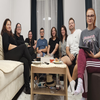

In [9]:
def scale_image_to_width_and_height(img, target_width, target_height, print_aspect_mismatch=False):
    """Scale an image to the target width and height while maintaining the aspect ratio."""

    # Get the original dimensions of the image
    original_width, original_height = img.size

    # Calculate the missmatch in aspect ratio and print it if desired
    if print_aspect_mismatch:
        aspect_original = original_width / original_height
        aspect_target = target_width / target_height
        print(f"Difference in aspect ratio: {aspect_original - aspect_target:.2f}")

    # Return the resized image
    return img.resize((target_width, target_height), Image.Resampling.LANCZOS)

img = Image.open(image_files[2])
scale_image_to_width_and_height(img, 100, 100)

In [10]:
def add_border_to_image(img, image_width_px, image_height_px, border_color='white'):
    """Add a border to an image to fit it into the target dimensions."""

    # Create a new image with the target dimensions and the specified border color
    bordered_img = Image.new('RGB', (image_width_px, image_height_px), border_color)

    # Paste the original image onto the bordered image
    x_y_offset = mm_to_pixel(side_border_mm, dpi)
    bordered_img.paste(img, (x_y_offset, x_y_offset))

    return bordered_img

img = Image.open(image_files[2])
scaled_img = scale_image_to_width_and_height(img, picture_width_px, picture_height_px)
bordered_img = add_border_to_image(scaled_img, image_width_px, image_height_px)

# Save the processed image
output_dir = path_to_input_dir.parent / 'processed_images'
output_dir.mkdir(exist_ok=True)
bordered_img.save(output_dir / 'processed_image.jpg')

In [11]:
def add_description_and_date(img, description='', date='', font_path=None, font_size=42):
    """Add a description and date to the bottom of the image.
    Uses font metrics for vertical layout, so descenders (p, q, j, ...) do not shift text position."""

    # Create a image box for the description and date
    description_box_height_px = mm_to_pixel(bottom_border_mm, dpi)
    description_box = Image.new('RGB', (img.width, description_box_height_px), 'white')

    # Add the description and date to the description box
    draw = ImageDraw.Draw(description_box)
    try:
        if font_path:
            font = ImageFont.truetype(font_path, int(font_size))
            font_date = ImageFont.truetype(font_path, int(font_size / 2))
        else:
            font = ImageFont.truetype('C:/Windows/Fonts/arial.ttf', int(font_size))
            font_date = ImageFont.truetype('C:/Windows/Fonts/arial.ttf', int(font_size / 2))
    except OSError:
        print(f"Could not load font from {font_path}. Using default font.")
        font = ImageFont.load_default()
        font_date = ImageFont.load_default()

    # Stable line heights from font metrics (independent from specific letters)
    descr_ascent, descr_descent = font.getmetrics()  # type: ignore
    descr_line_height = descr_ascent + descr_descent

    if date:
        date_ascent, date_descent = font_date.getmetrics()  # type: ignore
        date_line_height = date_ascent + date_descent
    else:
        date_line_height = 0

    gap = 5 if date else 0
    total_text_height = descr_line_height + gap + date_line_height

    # Top y of text block, then draw with 'ma' (middle, ascender) anchor
    y_top = max(0, (description_box.height - total_text_height) // 2)
    x_center = description_box.width // 2

    draw.text((x_center, y_top), description, fill='black', font=font, anchor='ma')

    if date:
        y_date = y_top + descr_line_height + gap
        draw.text((x_center, y_date), date, fill='black', font=font_date, anchor='ma')

    # Paste the description box onto the original image
    img.paste(description_box, (0, img.height - description_box_height_px))

    return img

img = Image.open(image_files[2])
scaled_img = scale_image_to_width_and_height(img, picture_width_px, picture_height_px, print_aspect_mismatch=True)
bordered_img = add_border_to_image(scaled_img, image_width_px, image_height_px)

image_with_text = add_description_and_date(
    bordered_img,
    description='Beispielbild mit Menschen drauf',
    date='August 2024',
    font_path='C:/Windows/Fonts/Calibri.ttf',
    font_size=60
)

Difference in aspect ratio: -0.03


In [12]:
# Load the edited image information from the Excel file
edited_img_info_df = pd.read_excel(path_to_input_dir.parent / f'image_info_{ORIENTATION}_bearbeitet.xlsx')

# Map the month number to the month name in German (or any other language as needed)
month_dict = {
    1: 'Jänner',
    2: 'Februar',
    3: 'März',
    4: 'April',
    5: 'Mai',
    6: 'Juni',
    7: 'Juli',
    8: 'August',
    9: 'September',
    10: 'Oktober',
    11: 'November',
    12: 'Dezember',
    }

# Map the name of the month to the month number in the 'Date corrected' column
edited_img_info_df['Month'] = edited_img_info_df['Date corrected'].dt.month.map(month_dict)

# Create a 'Date for text' column with the format "Month Year" (e.g., "August 2024")
edited_img_info_df['Date text'] = edited_img_info_df['Month'] + ' ' + edited_img_info_df['Date corrected'].dt.year.astype(str)

# Drop the columns as they're no longer needed
edited_img_info_df = edited_img_info_df.drop(columns=['Month', 'Date corrected'])
edited_img_info_df

,Filename,Description,Width (px),Height (px),Date,Date text
0,achensee.jpg,Babysitten am Achensee,4000,2252,2025:05:10 12:15:08,Mai 2025
1,babyparty nadia.jpg,Nadias Babyparty,1971,1183,NaN,August 2025
2,bei stefi und darko.jpg,Zu Besuch bei Stefi,4000,3000,2024:10:05 19:55:52,Oktober 2024
3,besuch aus mkd.JPG,Besuch aus Mazedonien,4000,3000,2020:01:03 17:41:40,Jänner 2020
4,brunch in ibk.jpg,Brunch in Innsbruck,4032,3024,2022:09:03 14:05:37,September 2022
...,...,...,...,...,...,...
57,weißenstein und dorf.JPG,Geburtstagsessen Franz,6000,4000,2022:12:26 14:51:44,Dezember 2022
58,wilten frühstücken.jpg,Brunch in Wilten,3088,2320,2023:11:18 10:23:38,November 2023
59,wk ausflug prag.JPG,WK Ausflug Prag,6000,4000,2024:04:27 11:48:59,April 2024
60,wk winterausflug seiseralm.jpg,WK Winterausflug Seiser Alm,1600,1200,NaN,Februar 2022


In [13]:
# Loop through the edited image information and process each image accordingly
for index, row in edited_img_info_df.iterrows():

    img = Image.open(path_to_input_dir / row['Filename'])
    scaled_img = scale_image_to_width_and_height(img, picture_width_px, picture_height_px, print_aspect_mismatch=True)
    bordered_img = add_border_to_image(scaled_img, image_width_px, image_height_px)

    image_with_text = add_description_and_date(
        bordered_img,
        description=row['Description'],
        date=row['Date text'],
        font_path='C:/Windows/Fonts/Calibri.ttf',
        font_size=60
    )
    image_with_text.save(output_dir / f"processed_{row['Filename']}")

Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in aspect ratio: -0.03
Difference in 

# Combine for printing

In [14]:
# Define the printing directory and create it if it doesn't exist
printing_dir = path_to_input_dir.parent / 'printing'
printing_dir.mkdir(exist_ok=True)

# Get list of processed images
processed_images = list(output_dir.glob('*.jpg'))
print(f"Processed {len(processed_images)} images with descriptions and dates")

Processed 62 images with descriptions and dates


In [15]:
def combine_images_for_printing(image_files, images_per_row, images_per_col, output_path):
    """Combine processed images into one or more print sheets."""

    images_per_page = images_per_row * images_per_col
    total_images = len(image_files)
    total_pages = math.ceil(total_images / images_per_page)

    output_path = Path(output_path)
    base_name = output_path.stem
    suffix = output_path.suffix if output_path.suffix else '.jpg'

    for page_index in range(total_pages):
        start = page_index * images_per_page
        end = start + images_per_page
        page_images = image_files[start:end]

        # Calculate the size of the combined image
        combined_width = image_width_px * images_per_row
        combined_height = image_height_px * images_per_col

        # Create a new blank image for this page
        combined_image = Image.new('RGB', (combined_width, combined_height), 'white')

        # Paste page images into the current sheet
        for index, image_file in enumerate(page_images):
            img = Image.open(image_file)
            row = index // images_per_row
            col = index % images_per_row
            x_offset = col * image_width_px
            y_offset = row * image_height_px
            combined_image.paste(img, (x_offset, y_offset))

        # Draw 1px gray separator lines between images
        draw = ImageDraw.Draw(combined_image)
        line_color = (180, 180, 180)

        for col in range(1, images_per_row):
            x = col * image_width_px
            draw.line([(x, 0), (x, combined_height)], fill=line_color, width=1)

        for row in range(1, images_per_col):
            y = row * image_height_px
            draw.line([(0, y), (combined_width, y)], fill=line_color, width=1)

        # Save page with numbering
        page_output = output_path.with_name(f"{base_name}_{page_index + 1:02d}{suffix}")
        combined_image.save(page_output)
        print(f"Saved: {page_output}")

combine_images_for_printing(
    image_files=processed_images,
    images_per_row=1,
    images_per_col=2,
    output_path=printing_dir / "combined_printing.jpg"
 )

Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\printing\combined_printing_01.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\printing\combined_printing_02.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\printing\combined_printing_03.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\printing\combined_printing_04.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\printing\combined_printing_05.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\printing\combined_printing_06.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\printing\combined_printing_07.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\printing\combined_printing_08.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\printing\combined_printing_09.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\printing\combined_printing_10.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos\printing\combined_printing_11.jpg
Saved: C:\Users\thoma